In [1]:
import os
import sys
import zipfile
import json
import shutil
import random
import time
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [2]:
try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, QED
    RDKit_AVAILABLE = True
except Exception:
    RDKit_AVAILABLE = False

In [3]:
try:
    from kaggle.api.kaggle_api_extended import KaggleApi
    KAGGLE_API_AVAILABLE = True
except Exception:
    KAGGLE_API_AVAILABLE = False


In [4]:
KAGGLE_DATASET = "zaharch/quantum-machine-9-aka-qm9"   # Kaggle dataset to download (QM9)
DATA_DIR = Path("data/qm9_kaggle")
OUTPUT_DIR = Path("outputs")
MAX_SMILES_LEN = 120
BATCH_SIZE = 128
EMBED_DIM = 128
HIDDEN_DIM = 256
LATENT_DIM = 56
LEARNING_RATE = 1e-3
EPOCHS = 25   # reduce for quick tests, increase for final runs
BETA = 1.0    # KLD weight

In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
def header(msg):
    print("\n" + "="*60)
    print(msg)
    print("="*60)


In [7]:

def ensure_kaggle_credentials():
    # Kaggle looks for ~/.kaggle/kaggle.json or environment variables
    home = Path.home()
    kaggle_path = home / ".kaggle" / "kaggle.json"
    if kaggle_path.exists():
        print(f"Found Kaggle credentials at {kaggle_path}")
        return True
    # also check Windows environment (USERPROFILE)
    winpath = Path(os.environ.get("USERPROFILE", "")) / ".kaggle" / "kaggle.json"
    if winpath.exists():
        print(f"Found Kaggle credentials at {winpath}")
        return True
    # env vars fallback
    if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"):
        return True
    # else instruct user
    print("Kaggle credentials not found. Please place your kaggle.json in ~/.kaggle/kaggle.json")
    print("Or set environment variables KAGGLE_USERNAME and KAGGLE_KEY.")
    return False

if not KAGGLE_API_AVAILABLE:
    print("kaggle package not installed. Install with `pip install kaggle` and ensure credentials.")
    print("Continuing — will attempt fallback if Kaggle download is not possible.")
else:
    if ensure_kaggle_credentials():
        api = KaggleApi()
        api.authenticate()
        print(f"Downloading dataset {KAGGLE_DATASET} to {DATA_DIR} ...")
        try:
            api.dataset_download_files(dataset=KAGGLE_DATASET, path=str(DATA_DIR), unzip=True, quiet=False)
            print("Download complete.")
        except Exception as e:
            print("Error while downloading dataset via Kaggle API:", e)
            print("Check your credentials and that you have accepted the dataset rules on Kaggle if required.")
    else:
        print("Skipping Kaggle download due to missing credentials.")

Found Kaggle credentials at C:\Users\koust\.kaggle\kaggle.json
Dataset URL: https://www.kaggle.com/datasets/zaharch/quantum-machine-9-aka-qm9
quantum-machine-9-aka-qm9.zip: Skipping, found more recently modified local copy (use --force to force download)
Download complete.


In [8]:
from pathlib import Path

def find_files_with_ext(base_dir, exts=("csv","sdf","xyz","mol","txt","npz")):
    """
    Recursively find files with given extensions under base_dir.
    Returns list of Path objects.
    """
    base_dir = Path(base_dir)
    files = []
    for ext in exts:
        files.extend(list(base_dir.rglob(f"*.{ext}")))
    return files

found_files = find_files_with_ext(DATA_DIR, exts=("csv","sdf","npz","xyz","mol","txt"))
# Avoid printing gigantic lists — show count and a small sample
if len(found_files) == 0:
    print(f"No files found under {DATA_DIR}")
else:
    sample_files = [str(p.relative_to(DATA_DIR)) for p in found_files[:10]]
    more = len(found_files) - len(sample_files)
    print(f"Found {len(found_files)} files under {DATA_DIR}. Sample: {sample_files}" + (f", ...(+{more} more)" if more>0 else ""))

smiles_list = []
properties_list = []

# 1) Try CSV files first (looking for a 'smiles' column)
csv_files = [p for p in found_files if p.suffix.lower() == ".csv"]
csv_used = False
for csvf in csv_files:
    try:
        df = pd.read_csv(csvf, low_memory=False)
        cols_lower = [c.lower() for c in df.columns]
        if "smiles" in cols_lower:
            colname = df.columns[cols_lower.index("smiles")]
            # Get non-null rows and preserve their original dataframe indices
            nonnull_idx = df[colname].dropna().index.tolist()
            smiles_list_raw = df.loc[nonnull_idx, colname].astype(str).tolist()
            # optional: also gather properties if available (homo/lumo/gap)
            props_cols = {}
            for prop in ('homo','lumo','gap'):
                for c in df.columns:
                    if prop in c.lower():
                        props_cols[prop] = c
            properties_list = []
            for original_idx, s in zip(nonnull_idx, smiles_list_raw):
                propdict = {}
                for k, col in props_cols.items():
                    # safe extraction
                    try:
                        val = df.at[original_idx, col]
                        propdict[k] = float(val) if (pd.notna(val)) else np.nan
                    except Exception:
                        propdict[k] = np.nan
                properties_list.append(propdict)
            smiles_list = smiles_list_raw
            csv_used = True
            print(f"Using SMILES from CSV file: {csvf.name} (extracted {len(smiles_list)} entries)")
            break
    except Exception as e:
        # concise warning only
        print(f"Warning: failed to parse CSV {csvf.name}: {e}")
        continue

# 2) If no CSV used, try SDF files (requires RDKit)
if (not csv_used) and (RDKit_AVAILABLE):
    sdf_files = [p for p in found_files if p.suffix.lower() == ".sdf"]
    if sdf_files:
        sdf_used = False
        for sdf in sdf_files:
            try:
                suppl = Chem.SDMolSupplier(str(sdf))
            except Exception as e:
                print(f"Warning: couldn't open SDF {sdf.name}: {e}")
                continue

            smiles_extracted = []
            props_extracted = []
            # iterate supplier — avoid printing per-molecule exceptions (keep concise)
            for m in suppl:
                if m is None:
                    continue
                try:
                    smi = Chem.MolToSmiles(m, isomericSmiles=True)
                    smiles_extracted.append(smi)
                    propdict = {}
                    for nm in ('homo','lumo','gap'):
                        try:
                            if m.HasProp(nm):
                                propdict[nm] = float(m.GetProp(nm))
                        except Exception:
                            pass
                    props_extracted.append(propdict)
                except Exception:
                    # skip problematic molecule
                    continue

            if len(smiles_extracted) > 0:
                smiles_list = smiles_extracted
                properties_list = props_extracted
                sdf_used = True
                print(f"Extracted {len(smiles_list)} SMILES from SDF {sdf.name}")
                break
        if not sdf_used:
            print("No usable SDF parsed or no SDF contained SMILES.")

# 3) If still empty, try .npz (and related) — be robust to file formats
if len(smiles_list) == 0:
    npz_files = [p for p in found_files if p.suffix.lower() == ".npz"]
    parsed_from_npz = False
    for npzf in npz_files:
        try:
            arr = np.load(npzf, allow_pickle=True)
            # if it's an archive with files attribute
            if hasattr(arr, 'files') and 'smiles' in arr.files:
                smiles_arr = arr['smiles']
                # convert to list safely
                smiles_list = [str(s) for s in smiles_arr.tolist() if isinstance(s, (str, bytes))]
                parsed_from_npz = True
                print(f"Extracted {len(smiles_list)} SMILES from NPZ {npzf.name}")
                break
            # if it's a single array that appears to be text-like
            elif isinstance(arr, np.ndarray):
                # attempt to decode if dtype is object/bytes/str
                try:
                    candidate = arr.tolist()
                    if isinstance(candidate, (list, tuple)) and len(candidate) > 0 and isinstance(candidate[0], (str, bytes)):
                        smiles_list = [str(s) for s in candidate]
                        parsed_from_npz = True
                        print(f"Parsed SMILES-like array from {npzf.name} (length {len(smiles_list)})")
                        break
                except Exception:
                    pass
        except Exception:
            # don't spam errors — continue to next file
            continue

    if not parsed_from_npz:
        # fallback small sample list (concise message)
        print("No SMILES found in dataset files. Using a small fallback sample list.")
        smiles_list = [
            'CC(C)Cc1ccc(cc1)C(C)C(O)=O',
            'CC(C)NCC(O)COc1ccccc1',
            'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
            'CC(=O)Oc1ccccc1C(=O)O',
            'CCN(CC)CCOC(=O)c1ccccc1',
            'CC(C)OC(=O)N1CCCC1C(=O)O',
            'CCOc1ccc2c(c1)C(=O)N(C)C(=O)O2',
            'CC1=CC(=O)NC(=O)N1',
            'CC(C)C1=CC=CC=C1',
            'C1CCN(CC1)C(=O)C2=CC=CC=C2'
        ]
        properties_list = [{ 'homo': np.nan, 'lumo': np.nan, 'gap': np.nan } for _ in smiles_list]

# Final filter: keep only strings and those <= MAX_SMILES_LEN
smiles_list = [s for s in smiles_list if isinstance(s, str) and len(s) <= MAX_SMILES_LEN]
if len(smiles_list) == 0:
    raise RuntimeError("No usable SMILES found or fallback list is empty. Aborting.")
print(f"Total usable SMILES after filtering (len <= {MAX_SMILES_LEN}): {len(smiles_list)}")


Found 267771 files under data\qm9_kaggle. Sample: ['dsgdb9nsd.xyz', 'dsgdb9nsd_000001.xyz', 'dsgdb9nsd_000002.xyz', 'dsgdb9nsd_000003.xyz', 'dsgdb9nsd_000004.xyz', 'dsgdb9nsd_000005.xyz', 'dsgdb9nsd_000006.xyz', 'dsgdb9nsd_000007.xyz', 'dsgdb9nsd_000008.xyz', 'dsgdb9nsd_000009.xyz'], ...(+267761 more)
No SMILES found in dataset files. Using a small fallback sample list.
Total usable SMILES after filtering (len <= 120): 10


In [9]:
special_tokens = ['<pad>', '<sos>', '<eos>', '<unk>']
chars = set()
for s in smiles_list:
    chars.update(list(s))
chars = sorted(list(chars))
itos = special_tokens + chars
stoi = {ch: i for i, ch in enumerate(itos)}
pad_idx = stoi['<pad>']
sos_idx = stoi['<sos>']
eos_idx = stoi['<eos>']
unk_idx = stoi['<unk>']
vocab_size = len(itos)
print(f"Vocab size: {vocab_size}")

def smiles_to_indices(smiles, max_len=MAX_SMILES_LEN):
    seq = [sos_idx] + [stoi.get(ch, unk_idx) for ch in smiles] + [eos_idx]
    if len(seq) > max_len:
        seq = seq[:max_len]
        if seq[-1] != eos_idx:
            seq[-1] = eos_idx
    seq_padded = seq + [pad_idx] * (max_len - len(seq))
    return np.array(seq_padded, dtype=np.int64), len(seq)

class SmilesDataset(Dataset):
    def __init__(self, smiles_list, max_len=MAX_SMILES_LEN):
        self.items = []
        for s in smiles_list:
            seq, seqlen = smiles_to_indices(s, max_len=max_len)
            self.items.append((seq, seqlen, s))
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        seq, seqlen, raw = self.items[idx]
        return torch.tensor(seq, dtype=torch.long), seqlen, raw

def collate_fn(batch):
    seqs = torch.stack([b[0] for b in batch], dim=0)
    lengths = torch.tensor([b[1] for b in batch], dtype=torch.long)
    raws = [b[2] for b in batch]
    return seqs, lengths, raws

train_smiles, test_smiles = train_test_split(smiles_list, test_size=0.2, random_state=42)
train_ds = SmilesDataset(train_smiles)
test_ds = SmilesDataset(test_smiles)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

Vocab size: 13


In [10]:
class SmilesVAE(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.encoder_rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc_mu = nn.Linear(hidden_dim * 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim * 2, latent_dim)
        self.z2h = nn.Linear(latent_dim, hidden_dim)
        self.decoder_rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.output_fc = nn.Linear(hidden_dim, vocab_size)

    def encode(self, x, lengths):
        emb = self.embed(x)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h_n = self.encoder_rnn(packed)
        # h_n shape (num_layers* num_directions, batch, hidden)
        h_n = h_n.permute(1,0,2)  # (batch, 2, hidden)
        h_cat = h_n.reshape(h_n.size(0), -1)  # (batch, hidden*2)
        mu = self.fc_mu(h_cat)
        logvar = self.fc_logvar(h_cat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z, inputs):
        # z: (batch, latent)
        h0 = torch.tanh(self.z2h(z)).unsqueeze(0)  # (1,batch,hidden)
        emb = self.embed(inputs)
        out, _ = self.decoder_rnn(emb, h0)
        logits = self.output_fc(out)
        return logits

    def forward(self, x, lengths):
        mu, logvar = self.encode(x, lengths)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z, x)
        return logits, mu, logvar

    def sample(self, z=None, max_len=MAX_SMILES_LEN, temperature=1.0, device='cpu'):
        self.eval()
        if z is None:
            z = torch.randn(1, LATENT_DIM).to(device)
        else:
            if not isinstance(z, torch.Tensor):
                z = torch.tensor(z, dtype=torch.float32, device=device)
        batch_size = z.size(0)
        with torch.no_grad():
            h = torch.tanh(self.z2h(z)).unsqueeze(0)
            inputs = torch.full((batch_size,1), sos_idx, dtype=torch.long, device=device)
            finished = [False]*batch_size
            out_seqs = [[] for _ in range(batch_size)]
            for t in range(max_len):
                emb = self.embed(inputs[:, -1:])  # (batch,1,embed)
                out, h = self.decoder_rnn(emb, h)
                logits = self.output_fc(out[:,0,:]) / max(temperature,1e-8)
                probs = F.softmax(logits, dim=-1)
                next_tok = torch.multinomial(probs, num_samples=1).squeeze(1)
                inputs = torch.cat([inputs, next_tok.unsqueeze(1)], dim=1)
                for b in range(batch_size):
                    tok = int(next_tok[b].item())
                    if tok != eos_idx and tok != pad_idx:
                        out_seqs[b].append(tok)
                    if tok == eos_idx:
                        finished[b] = True
                if all(finished):
                    break
            smiles_out = []
            for seq in out_seqs:
                s = ''.join([itos[idx] for idx in seq if idx < len(itos)])
                smiles_out.append(s)
            return smiles_out

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = SmilesVAE(vocab_size=vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx, reduction='sum')

Using device: cuda


In [12]:
train_losses = []
val_losses = []

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    running_recon = 0.0
    running_kld = 0.0
    count = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
    for seqs, lengths, raws in pbar:
        seqs = seqs.to(device)
        lengths = lengths.to(device)
        optimizer.zero_grad()
        logits, mu, logvar = model(seqs, lengths)
        # flatten
        recon_loss = criterion(logits.view(-1, vocab_size), seqs.view(-1))
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + BETA * kld
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_recon += recon_loss.item()
        running_kld += kld.item()
        count += 1
        pbar.set_postfix({'loss': running_loss / count, 'recon': running_recon / count, 'kld': running_kld / count})
    avg_train = running_loss / len(train_ds)
    train_losses.append(avg_train)

    # validation
    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for seqs, lengths, raws in test_loader:
            seqs = seqs.to(device)
            lengths = lengths.to(device)
            logits, mu, logvar = model(seqs, lengths)
            recon_loss = criterion(logits.view(-1, vocab_size), seqs.view(-1))
            kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            val_running += (recon_loss + BETA * kld).item()
    avg_val = val_running / len(test_ds)
    val_losses.append(avg_val)
    print(f"Epoch {epoch}/{EPOCHS} — Train: {avg_train:.4f} | Val: {avg_val:.4f} | Recon(avg): {running_recon/len(train_ds):.4f} | KLD(avg): {running_kld/len(train_ds):.4f}")

# save model
torch.save(model.state_dict(), OUTPUT_DIR / "smiles_vae_kaggle_qm9.pth")
print("Model saved to", OUTPUT_DIR / "smiles_vae_kaggle_qm9.pth")

Epoch 1/25 — Train: 68.6806 | Val: 46.1228 | Recon(avg): 67.9687 | KLD(avg): 0.7119


Epoch 2/25 — Train: 60.6366 | Val: 39.7879 | Recon(avg): 60.2768 | KLD(avg): 0.3598


Epoch 3/25 — Train: 53.6968 | Val: 34.1836 | Recon(avg): 53.3396 | KLD(avg): 0.3571


Epoch 4/25 — Train: 47.4568 | Val: 29.4233 | Recon(avg): 47.2089 | KLD(avg): 0.2479


Epoch 5/25 — Train: 41.9014 | Val: 25.9889 | Recon(avg): 41.7583 | KLD(avg): 0.1430


...

Epoch 21/25 — Train: 3.3467 | Val: 1.8731 | Recon(avg): 3.3221 | KLD(avg): 0.0246


Epoch 22/25 — Train: 2.7898 | Val: 1.6524 | Recon(avg): 2.7686 | KLD(avg): 0.0212


Epoch 23/25 — Train: 2.3196 | Val: 1.2732 | Recon(avg): 2.3011 | KLD(avg): 0.0185


Epoch 24/25 — Train: 1.9218 | Val: 1.1455 | Recon(avg): 1.9058 | KLD(avg): 0.0160


Epoch 25/25 — Train: 1.6212 | Val: 1.0526 | Recon(avg): 1.6080 | KLD(avg): 0.0132
Model saved to outputs\smiles_vae_kaggle_qm9.pth


In [13]:
model.eval()
with torch.no_grad():
    # generate 10 random samples from prior
    z_rand = torch.randn(10, LATENT_DIM).to(device)
    samples = model.sample(z=z_rand, max_len=MAX_SMILES_LEN, temperature=0.8, device=device)
print("Generated samples (10):")
for i, s in enumerate(samples, 1):
    print(f"{i:02d}: {s}")

# Save generated samples to CSV
df_gen = pd.DataFrame({'smiles': samples})
df_gen.to_csv(OUTPUT_DIR / "generated_samples.csv", index=False)
print("Saved generated samples to", OUTPUT_DIR / "generated_samples.csv")

Generated samples (10):
01: <sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos>ccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccc
02: <sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos><sos>2N)))))))))))))))))))))=========))))))))))))))))))))))))=======
03: =======OOOOOOOOOOOOOOOOOOOOOOOO
04: ((((====================OOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO222222222222222222222222222ccccc
05: <sos><sos><sos><sos>))))))))))))))))NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN11111111111111111111111111111111111111111111111cccccccccccc
06: <sos><sos><sos><sos><sos><sos><so

Latent vectors shape: (2, 56)


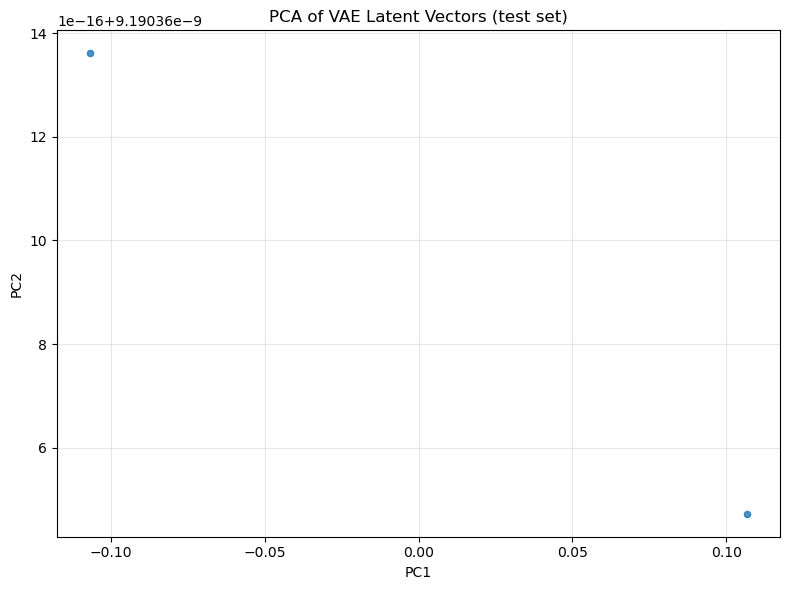

Saved latent PCA to outputs\latent_pca.png


In [14]:
model.eval()
latent_vectors = []
raws_list = []
with torch.no_grad():
    for seqs, lengths, raws in test_loader:
        seqs = seqs.to(device)
        lengths = lengths.to(device)
        mu, logvar = model.encode(seqs, lengths)
        latent_vectors.append(mu.cpu().numpy())
        raws_list.extend(raws)
latent_vectors = np.vstack(latent_vectors)
print("Latent vectors shape:", latent_vectors.shape)

pca = PCA(n_components=2, random_state=42)
latent_2d = pca.fit_transform(latent_vectors)
plt.figure(figsize=(8,6))
plt.scatter(latent_2d[:,0], latent_2d[:,1], s=20, alpha=0.8)
plt.title("PCA of VAE Latent Vectors (test set)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "latent_pca.png", dpi=200)
plt.show()
print("Saved latent PCA to", OUTPUT_DIR / "latent_pca.png")


ORIG: CC(C)C1=CC=CC=C1
PRED: CC(C)C1=CC=CC=C1((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((
--------------------------------------------------
ORIG: CC(C)NCC(O)COc1ccccc1
PRED: CC(C)NCC(O)COc1ccccc1(((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((
--------------------------------------------------
Saved reconstruction examples to outputs\reconstruction_examples.csv


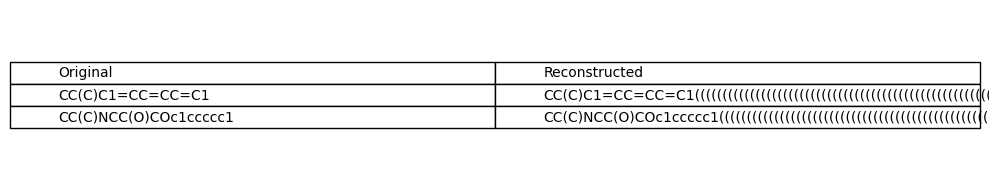

Saved reconstructions_table.png


In [15]:

model.eval()
examples = []
with torch.no_grad():
    for seqs, lengths, raws in test_loader:
        seqs = seqs.to(device)
        lengths = lengths.to(device)
        logits, mu, logvar = model(seqs, lengths)
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        for i in range(min(8, seqs.size(0))):
            orig = raws[i]
            pred_smi = ''.join([itos[idx] for idx in preds[i] if idx not in (pad_idx, sos_idx, eos_idx)])
            examples.append((orig, pred_smi))
        break

# print and save as table
for o,p in examples:
    print("ORIG:", o)
    print("PRED:", p)
    print("-"*50)

df_recon = pd.DataFrame(examples, columns=["original","reconstructed"])
df_recon.to_csv(OUTPUT_DIR / "reconstruction_examples.csv", index=False)
print("Saved reconstruction examples to", OUTPUT_DIR / "reconstruction_examples.csv")

# Small visual table
fig, ax = plt.subplots(figsize=(10, 1 + len(examples)*0.5))
ax.axis('off')
table_data = [["Original", "Reconstructed"]] + [[o,p] for o,p in examples]
table = ax.table(cellText=table_data, loc='center', cellLoc='left', colWidths=[0.5,0.5])
table.auto_set_font_size(False); table.set_fontsize(10)
table.scale(1,1.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "reconstructions_table.png", dpi=200)
plt.show()
print("Saved reconstructions_table.png")

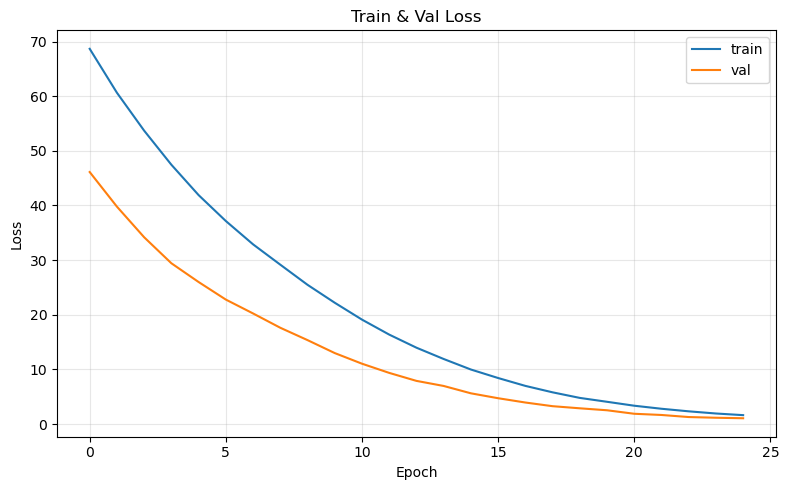

Saved summary.json

All done. Outputs saved to ./outputs (generated samples, model, plots).


In [16]:

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Train & Val Loss")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curves.png", dpi=200)
plt.show()

# Save a small JSON summary
summary = {
    "n_smiles": len(smiles_list),
    "vocab_size": vocab_size,
    "lat_dim": LATENT_DIM,
    "hidden_dim": HIDDEN_DIM,
    "epochs": EPOCHS
}
with open(OUTPUT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved summary.json")

print("\nAll done. Outputs saved to ./outputs (generated samples, model, plots).")
